In [1]:


# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ML libraries
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Regression metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# Load diabetes dataset
data = load_diabetes()

# Features and target
X = data.data
y = data.target

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (442, 10)
Target Shape: (442,)


In [3]:
# Convert to DataFrame
df = pd.DataFrame(X, columns=data.feature_names)

# Add target column
df["target"] = y

# Display first 5 rows
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [4]:
# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (353, 10)
Testing Shape: (89, 10)


In [5]:
# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [6]:
# Make predictions
y_pred = model.predict(X_test)

# Show first 5 predictions
print("Predictions:", y_pred[:5])

Predictions: [139.5475584  179.51720835 134.03875572 291.41702925 123.78965872]


In [7]:
# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error
rmse = np.sqrt(mse)

# R2 Score
r2 = r2_score(y_test, y_pred)

# Adjusted R2 Score
n = X_test.shape[0]   # number of samples
p = X_test.shape[1]   # number of features

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

# Print results
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)
print("Adjusted R2 :", adjusted_r2)

MAE : 42.79409467959994
MSE : 2900.1936284934804
RMSE : 53.85344583676592
R2 Score : 0.4526027629719197
Adjusted R2 : 0.3824236300196018


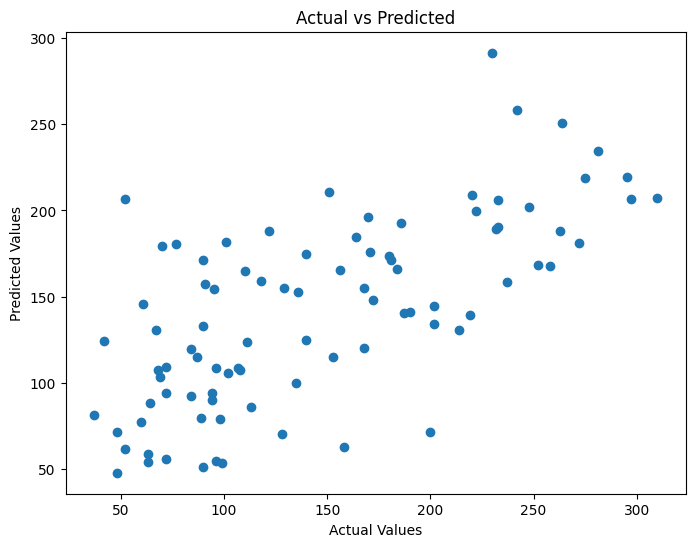

In [8]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.show()

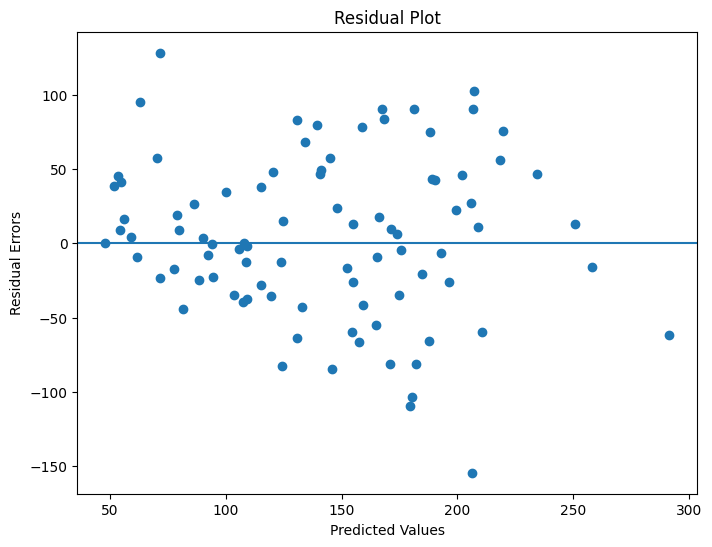

In [9]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Values")
plt.ylabel("Residual Errors")
plt.title("Residual Plot")

plt.show()